# 01 - Business Context & Exploratory Data Analysis

## Análisis del contexto logístico y exploración operacional del dataset

En este notebook se realiza el análisis exploratorio del dataset logístico preparado previamente en `00_data_cleaning_feature_engineering.ipynb`.

La finalidad de esta etapa es comprender qué está ocurriendo dentro de la operación logística antes de avanzar hacia modelos predictivos.

El foco principal estará en analizar:

- composición general del dataset;
- tipos de carga transportada;
- estado de los vehículos;
- tipos de vía utilizados;
- comportamiento de peso, distancia, velocidad y capacidad;
- distribución del riesgo operacional;
- relaciones entre variables operacionales;
- hallazgos relevantes para el negocio.

Este notebook responde a la pregunta:

> ¿Qué está pasando en la operación logística?


# Objetivo del notebook

En esta etapa busco comprender el comportamiento del dataset desde una perspectiva de negocio y operación.

Los objetivos específicos son:

- describir el contexto del problema logístico;
- revisar la estructura general del dataset V3;
- analizar variables clave de envíos, rutas y vehículos;
- estudiar la distribución de riesgo operacional;
- identificar patrones asociados a sobrecarga, distancia y velocidad;
- analizar correlaciones relevantes;
- obtener hallazgos que justifiquen las predicciones de riesgo utilizadas más adelante.

A diferencia del notebook 00, aquí no se hacen transformaciones fuertes.  
El objetivo es interpretar los datos ya preparados y entender su valor operacional.


# Contexto de negocio

El dataset representa una operación logística compuesta por:

- envíos;
- rutas de distribución;
- vehículos;
- características de carga;
- tiempos estimados;
- incidencias;
- variables operacionales derivadas.

En una operación logística, no basta con saber si un envío fue entregado o no.  
También es importante comprender el nivel de exigencia de cada operación.

Un envío puede ser más riesgoso cuando combina factores como:

- carga pesada;
- alta utilización de capacidad;
- rutas largas;
- velocidades elevadas;
- vehículos en estado no óptimo;
- vías complejas.

Por esta razón, el análisis se centra en entender el comportamiento operacional y el riesgo asociado a los envíos.


# 1. Configuración inicial

Importo las librerías necesarias y cargo el dataset V3 generado en la etapa anterior.


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

pd.set_option("display.max_columns", None)


# 2. Carga del dataset V3

Cargo el dataset limpio y transformado.

Este dataset fue generado en el notebook anterior y corresponde a la versión que será utilizada para análisis y modelado.


In [2]:
df_v3 = pd.read_csv("data/05_model_input/dataset_modelo_v3.csv")

print("Dimensiones del dataset V3:", df_v3.shape)

df_v3.head()


Dimensiones del dataset V3: (998, 56)


,id_envio,fecha_envio,id_ruta,id_vehiculo,peso_kg,volumen_m3,tipo_carga,estado,fecha_entrega,origen,destino,distancia_km,tiempo_estimado_hrs,tipo_via,peaje_total,placa,tipo,capacidad_kg,capacidad_m3,año_fabricacion,estado_vehiculo,km_recorridos,cantidad_incidencias,costo_total_incidencias,tipo_incidencia_principal,tiene_incidencia,dias_entrega,velocidad_promedio_km_h,uso_capacidad_kg,uso_capacidad_m3,entrega_tardia,peso_kg_original,distancia_km_original,velocidad_promedio_km_h_original,uso_capacidad_kg_original,uso_capacidad_m3_original,uso_capacidad_kg_recalculado,uso_capacidad_m3_recalculado,antiguedad_vehiculo,densidad_carga,riesgo_operacional,riesgo_velocidad,vehiculo_exigido,sobrecarga_kg,ruta_larga,velocidad_alta,vehiculo_riesgoso_estado,via_compleja,peso_kg_log,distancia_km_log,volumen_m3_log,velocidad_promedio_km_h_log,densidad_carga_log,riesgo_operacional_log,riesgo_velocidad_log,km_recorridos_log
0,1.0,2023-01-01,39.0,46.0,12675.8,28.48,peligrosa,entregado,2023-01-05,valparaíso,chillán,919.3,16.7,urbana,1950.0,ouuc-52,camión,10000.0,20.5,2022.0,en mantención,17043.0,0.0,0.0,sin incidencia,0.0,4.0,55.047904,1.26758,1.389268,1,12675.8,919.3,55.047904,1.26758,1.389268,1.26758,1.389268,4.0,445.061620,1165.286294,50605.538323,1,1,0,0,1,0,9.447529,6.824700,3.383712,4.026207,6.100457,7.061580,10.831836,9.743554
1,2.0,NaN,3.0,27.0,13.6,24.93,peligrosa,entregado,2023-01-05,rancagua,rengo,679.6,18.4,urbana,2447.0,fgkf-38,van,1000.0,22.1,2010.0,operativo,88004.0,0.0,0.0,sin incidencia,0.0,7.0,36.934783,0.01360,1.128054,1,13.6,679.6,36.934783,0.01360,1.128054,0.01360,1.128054,16.0,0.545506,9.242560,25100.878261,0,0,0,0,0,0,2.681022,6.522975,3.255401,3.635868,0.435351,2.326552,10.130698,11.385149
2,3.0,2023-01-02,73.0,18.0,2536.0,50.55,refrigerada,entregado,NaN,maipú,san antonio,468.4,5.2,ruta nacional,11768.0,agdn-22,furgón,20000.0,38.9,2023.0,en mantención,243705.0,0.0,0.0,sin incidencia,0.0,7.0,90.076923,0.12680,1.299486,1,2536.0,468.4,90.076923,0.12680,1.299486,0.12680,1.299486,3.0,50.167158,59.393120,42192.030769,0,0,0,0,1,1,7.838738,6.151455,3.942552,4.511704,3.935098,4.100875,10.650010,12.403718
3,4.0,2023-01-03,49.0,45.0,466.0,13.88,peligrosa,en tránsito,2023-01-07,las condes,osorno,1642.4,18.9,ruta nacional,7202.0,ialh-88,van,1000.0,25.3,2015.0,operativo,224573.5,1.0,1747372.0,desvío de ruta,1.0,4.0,86.899471,0.46600,0.548617,1,466.0,1642.4,86.899471,0.46600,0.548617,0.46600,0.548617,11.0,33.571068,765.358400,142723.691005,0,0,1,0,0,1,6.146329,7.404523,2.700018,4.476194,3.543017,6.641650,11.868673,12.321963
4,5.0,NaN,17.0,36.0,4928.9,0.44,refrigerada,retrasado,2023-01-07,maipú,rancagua,1556.6,17.9,urbana,3799.0,glfy-29,camioneta,5000.0,49.1,2023.0,operativo,138259.0,0.0,0.0,sin incidencia,0.0,7.0,86.960894,0.98578,0.008961,1,4928.9,1556.6,86.960894,0.98578,0.008961,0.98578,0.008961,3.0,11176.643991,1534.465148,135363.327374,1,0,1,0,0,0,8.503074,7.350901,0.364643,4.476892,9.321671,7.336589,11.815725,11.836891


## Análisis inicial

El dataset V3 contiene 998 registros y 56 columnas.

Esto indica que, después del proceso de limpieza y transformación, se conservó la mayor parte de los datos originales y se agregaron nuevas variables derivadas para representar mejor la operación logística.

Este dataset ya contiene variables originales tratadas, variables recalculadas, variables derivadas y transformaciones logarítmicas.


# 3. Revisión general de estructura

Reviso tipos de datos, columnas y valores faltantes para comprender la composición general del dataset.


In [3]:
df_v3.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 998 entries, 0 to 997
Data columns (total 56 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   id_envio                          998 non-null    float64
 1   fecha_envio                       461 non-null    object 
 2   id_ruta                           998 non-null    float64
 3   id_vehiculo                       998 non-null    float64
 4   peso_kg                           998 non-null    float64
 5   volumen_m3                        998 non-null    float64
 6   tipo_carga                        998 non-null    object 
 7   estado                            998 non-null    object 
 8   fecha_entrega                     463 non-null    object 
 9   origen                            998 non-null    object 
 10  destino                           998 non-null    object 
 11  distancia_km                      998 non-null    float64
 12  tiempo_e

In [4]:
print("Cantidad de filas:", df_v3.shape[0])
print("Cantidad de columnas:", df_v3.shape[1])

df_v3.columns.tolist()


Cantidad de filas: 998
Cantidad de columnas: 56



[
    'id_envio',
    'fecha_envio',
    'id_ruta',
    'id_vehiculo',
    'peso_kg',
    'volumen_m3',
    'tipo_carga',
    'estado',
    'fecha_entrega',
    'origen',
    'destino',
    'distancia_km',
    'tiempo_estimado_hrs',
    'tipo_via',
    'peaje_total',
    'placa',
    'tipo',
    'capacidad_kg',
    'capacidad_m3',
    'año_fabricacion',
    'estado_vehiculo',
    'km_recorridos',
    'cantidad_incidencias',
    'costo_total_incidencias',
    'tipo_incidencia_principal',
    'tiene_incidencia',
    'dias_entrega',
    'velocidad_promedio_km_h',
    'uso_capacidad_kg',
    'uso_capacidad_m3',
    'entrega_tardia',
    'peso_kg_original',
    'distancia_km_original',
    'velocidad_promedio_km_h_original',
    'uso_capacidad_kg_original',
    'uso_capacidad_m3_original',
    'uso_capacidad_kg_recalculado',
    'uso_capacidad_m3_recalculado',
    'antiguedad_vehiculo',
    'densidad_carga',
    'riesgo_operacional',
    'riesgo_velocidad',
    'vehiculo_exigido',
    'sob

In [5]:
nulos = df_v3.isnull().sum().sort_values(ascending=False)

nulos[nulos > 0].head(20)



fecha_envio                     537
fecha_entrega                   535
capacidad_m3                     27
capacidad_kg                     27
estado_vehiculo                  27
km_recorridos                    27
placa                            27
año_fabricacion                  27
tipo                             27
uso_capacidad_m3_recalculado     27
riesgo_operacional_log           27
km_recorridos_log                27
riesgo_operacional               27
antiguedad_vehiculo              27
uso_capacidad_kg_recalculado     27
dtype: int64

## Análisis de estructura

El dataset contiene variables numéricas, categóricas y fechas.

Los nulos restantes se concentran principalmente en fechas y algunas columnas asociadas a información vehicular.  
Esto no impide el análisis exploratorio, pero será importante en los modelos posteriores usar pipelines de imputación.

En esta etapa se prioriza entender los patrones operacionales generales.


# 4. Resumen estadístico de variables operacionales

Reviso las principales variables cuantitativas relacionadas con carga, distancia, velocidad, capacidad y riesgo.


In [6]:
variables_principales = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg_recalculado",
    "riesgo_operacional",
    "riesgo_velocidad"
]

df_v3[variables_principales].describe().T


,count,mean,std,min,25%,50%,75%,max
peso_kg,998.0,7860.699900,5340.718864,13.600000,3835.475000,7558.600000,11283.750000,40000.0
distancia_km,998.0,1026.657415,674.021421,29.600000,507.200000,919.300000,1492.800000,4000.0
velocidad_promedio_km_h,998.0,92.736315,59.472952,2.943396,40.136842,79.422222,155.914530,180.0
uso_capacidad_kg_recalculado,971.0,1.747518,1.626008,0.002410,0.498960,1.176100,2.510443,5.0
riesgo_operacional,971.0,1832.021294,2479.975768,0.355957,348.299907,925.223706,2279.954104,20000.0
riesgo_velocidad,998.0,119599.770365,126992.403801,91.833962,30397.719481,71619.702542,192456.000000,720000.0


## Análisis estadístico inicial

Los resultados muestran que el dataset V3 tiene rangos más controlados que el dataset original.

Algunos puntos importantes:

- el peso promedio es cercano a 7.860 kg;
- la distancia promedio es cercana a 1.027 km;
- la velocidad promedio se mantiene en un rango más razonable después del tratamiento;
- el uso de capacidad recalculado tiene valores máximos limitados;
- el riesgo operacional conserva una cola alta, lo que indica operaciones más exigentes;
- el riesgo por velocidad mantiene una escala amplia, coherente con la combinación de distancia y velocidad.

Esto confirma que el dataset conserva variabilidad operacional, pero con valores extremos más controlados.


# 5. Distribución por tipo de carga

Analizo qué tipos de carga aparecen con mayor frecuencia dentro de la operación.



tipo_carga
refrigerada    252
frágil         190
perecible      189
general        187
peligrosa      180
Name: count, dtype: int64

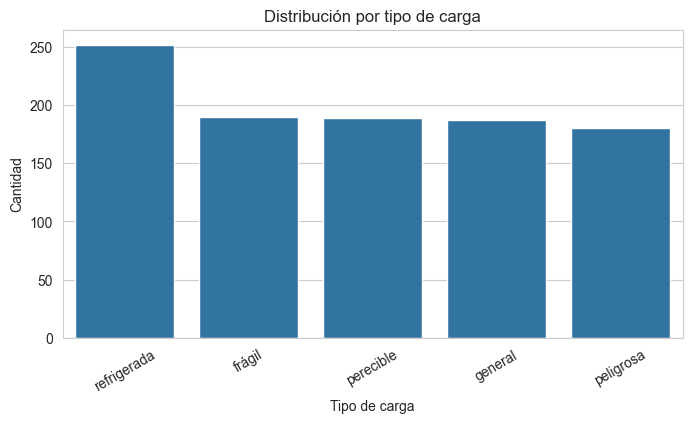

In [7]:
display(df_v3["tipo_carga"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(
    data=df_v3,
    x="tipo_carga",
    order=df_v3["tipo_carga"].value_counts().index
)

plt.title("Distribución por tipo de carga")
plt.xlabel("Tipo de carga")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)

plt.show()


## Análisis por tipo de carga

La distribución de tipos de carga es relativamente equilibrada.

La carga refrigerada aparece como la categoría más frecuente, seguida por cargas frágiles, perecibles, generales y peligrosas.

Desde una perspectiva logística, esta variedad es importante porque distintos tipos de carga pueden implicar diferentes niveles de cuidado, planificación y riesgo operacional.


# 6. Distribución por estado del vehículo

Analizo la condición de los vehículos utilizados en la operación.



estado_vehiculo
operativo            679
fuera de servicio    147
en mantención        145
Name: count, dtype: int64

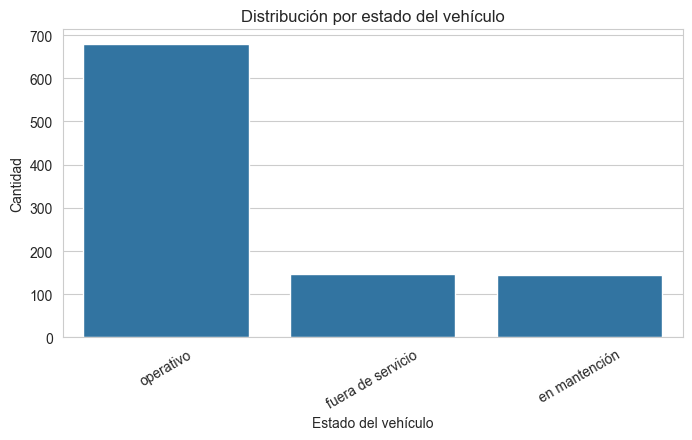

In [8]:
display(df_v3["estado_vehiculo"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(
    data=df_v3,
    x="estado_vehiculo",
    order=df_v3["estado_vehiculo"].value_counts().index
)

plt.title("Distribución por estado del vehículo")
plt.xlabel("Estado del vehículo")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)

plt.show()


## Análisis del estado vehicular

La mayoría de los vehículos se encuentra en estado operativo.

Sin embargo, también existen registros asociados a vehículos fuera de servicio o en mantención.  
Esto es relevante porque el estado del vehículo puede influir en la capacidad de respuesta, continuidad operacional y riesgo logístico.

Aunque el modelo no debe asumir automáticamente que un vehículo en mantención genera riesgo, esta variable entrega contexto importante sobre la flota.


# 7. Distribución por tipo de vía

Analizo la composición de rutas según tipo de vía.



tipo_via
urbana           396
autopista        269
ruta nacional    186
camino rural     147
Name: count, dtype: int64

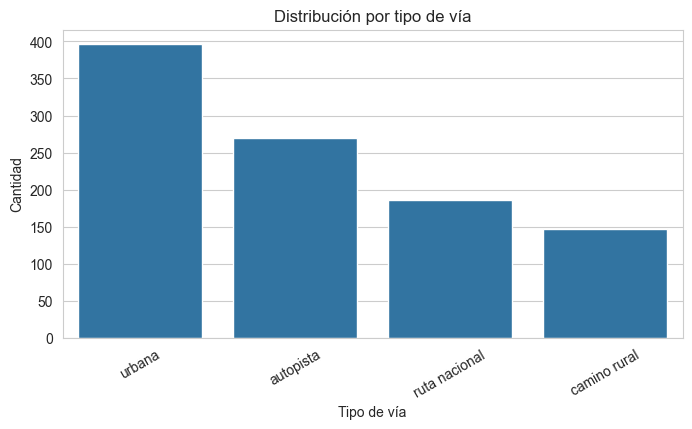

In [9]:
display(df_v3["tipo_via"].value_counts())

plt.figure(figsize=(8,4))
sns.countplot(
    data=df_v3,
    x="tipo_via",
    order=df_v3["tipo_via"].value_counts().index
)

plt.title("Distribución por tipo de vía")
plt.xlabel("Tipo de vía")
plt.ylabel("Cantidad")
plt.xticks(rotation=30)

plt.show()


## Análisis por tipo de vía

Las vías urbanas son las más frecuentes, seguidas por autopistas, rutas nacionales y caminos rurales.

Esta distribución permite observar que la operación combina contextos logísticos distintos:

- zonas urbanas;
- trayectos de mayor velocidad;
- rutas nacionales;
- caminos rurales potencialmente más complejos.

Esto justifica analizar variables como `via_compleja`, `ruta_larga` y `riesgo_velocidad`.


# 8. Distribuciones principales de variables numéricas

Visualizo la distribución de variables clave para entender la forma de los datos.


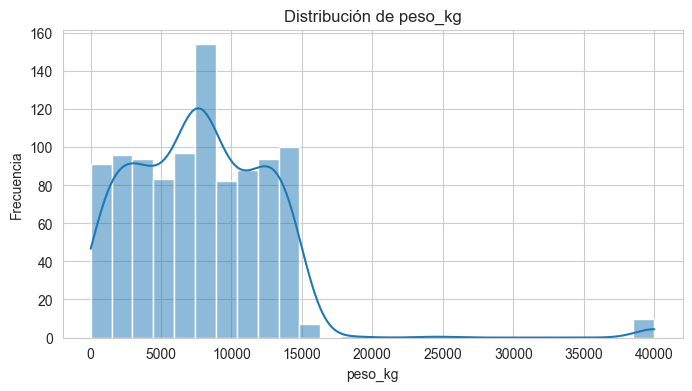

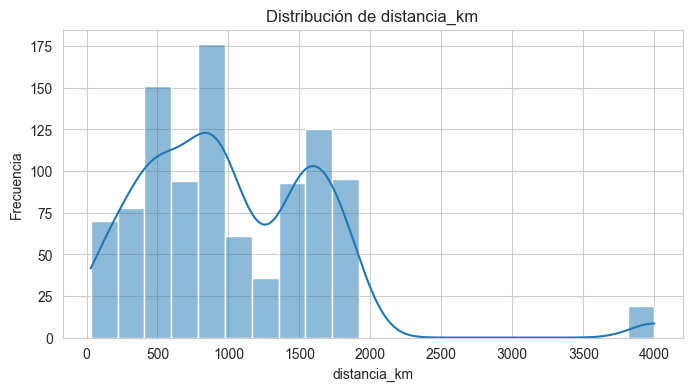

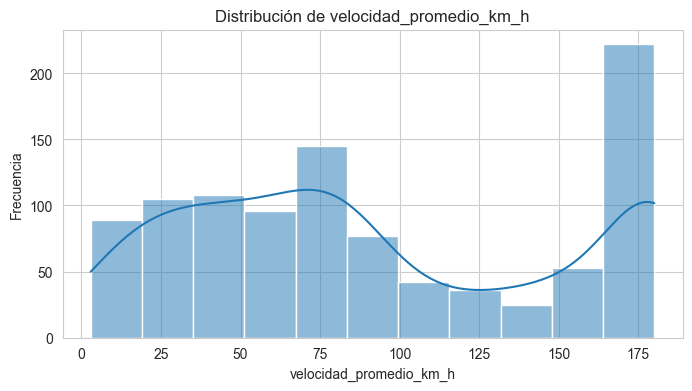

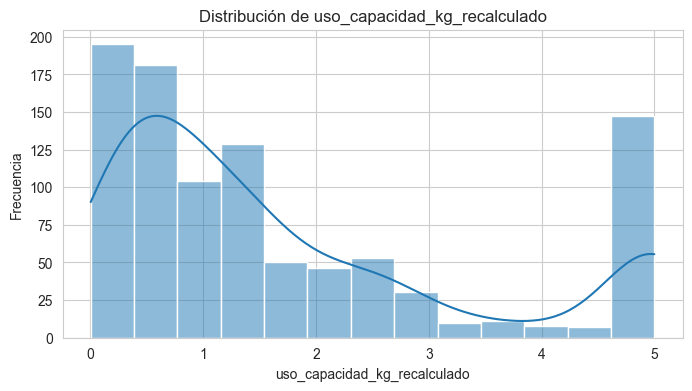

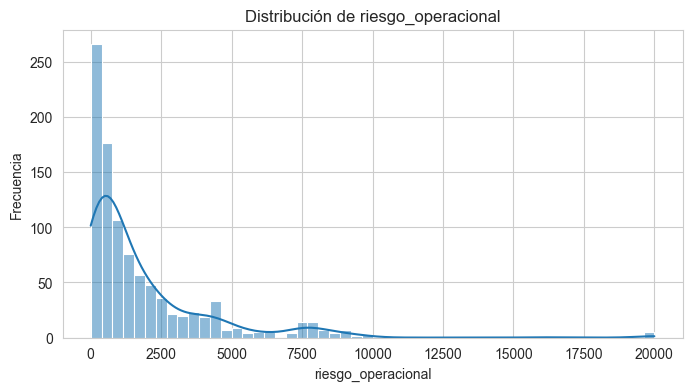

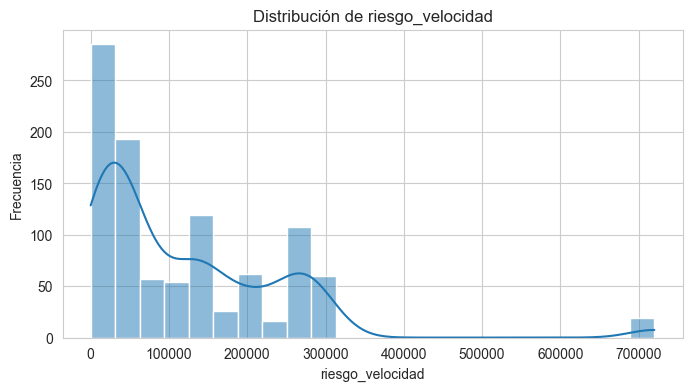

In [10]:
variables_distribucion = [
    "peso_kg",
    "distancia_km",
    "velocidad_promedio_km_h",
    "uso_capacidad_kg_recalculado",
    "riesgo_operacional",
    "riesgo_velocidad"
]

for col in variables_distribucion:
    plt.figure(figsize=(8,4))
    sns.histplot(df_v3[col], kde=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.show()


## Análisis de distribuciones

Las distribuciones muestran que varias variables presentan asimetría positiva.

Esto es esperable en operaciones logísticas, donde la mayoría de envíos se concentra en rangos moderados y algunos casos presentan valores mucho más altos.

El riesgo operacional, por ejemplo, presenta una gran concentración de envíos con riesgo bajo o medio, pero también una cola de operaciones más exigentes.


# 9. Distribución del riesgo operacional

El riesgo operacional es una de las variables centrales del proyecto.

Esta variable resume parte de la exigencia logística combinando distancia y uso de capacidad.


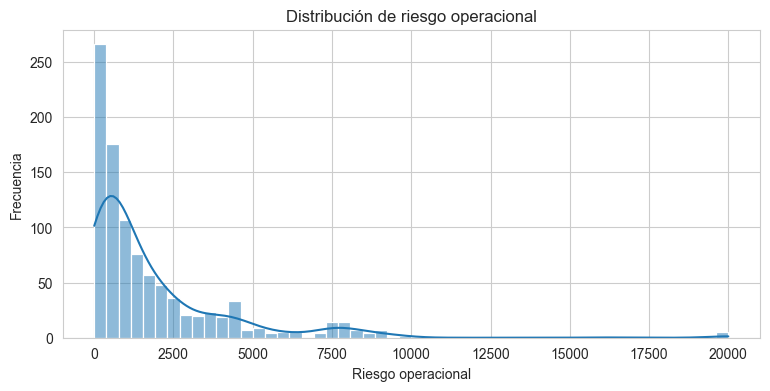


count      971.000000
mean      1832.021294
std       2479.975768
min          0.355957
25%        348.299907
50%        925.223706
75%       2279.954104
max      20000.000000
Name: riesgo_operacional, dtype: float64

In [11]:
plt.figure(figsize=(9,4))

sns.histplot(df_v3["riesgo_operacional"], kde=True)

plt.title("Distribución de riesgo operacional")
plt.xlabel("Riesgo operacional")
plt.ylabel("Frecuencia")

plt.show()

df_v3["riesgo_operacional"].describe()


## Análisis del riesgo operacional

El riesgo operacional tiene una distribución sesgada hacia la derecha.

La mayoría de envíos se concentra en niveles bajos o medios de riesgo, mientras que un grupo más pequeño alcanza valores altos.

Esto es muy útil para el proyecto, porque permite diferenciar operaciones normales de operaciones críticas.  
Además, esta variable puede utilizarse tanto como score continuo de riesgo como base para crear una clasificación de riesgo alto.


# 10. Vehículos exigidos

Analizo la proporción de envíos donde el vehículo opera cerca o por encima de un nivel exigente de capacidad.



vehiculo_exigido
1    562
0    436
Name: count, dtype: int64


vehiculo_exigido
1    56.312625
0    43.687375
Name: proportion, dtype: float64

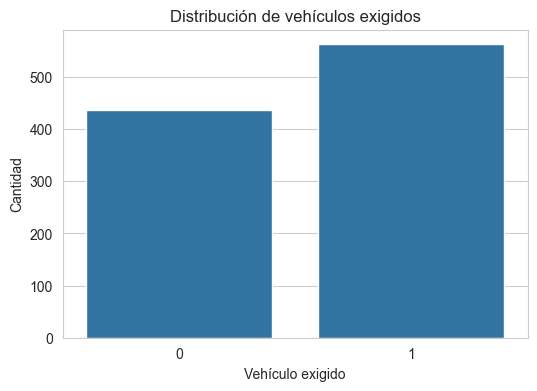

In [12]:
display(df_v3["vehiculo_exigido"].value_counts())
display(df_v3["vehiculo_exigido"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="vehiculo_exigido")

plt.title("Distribución de vehículos exigidos")
plt.xlabel("Vehículo exigido")
plt.ylabel("Cantidad")

plt.show()


## Análisis de vehículos exigidos

Más de la mitad de los registros corresponden a vehículos clasificados como exigidos.

Esto indica que una parte importante de la operación trabaja con altos niveles de utilización de capacidad.

Desde una perspectiva de negocio, esto puede representar eficiencia en el uso de recursos, pero también puede aumentar la exposición a riesgo operacional.


# 11. Sobrecarga de peso

Analizo cuántos envíos presentan sobrecarga según el ratio recalculado de capacidad.



sobrecarga_kg
1    528
0    470
Name: count, dtype: int64


sobrecarga_kg
1    52.905812
0    47.094188
Name: proportion, dtype: float64

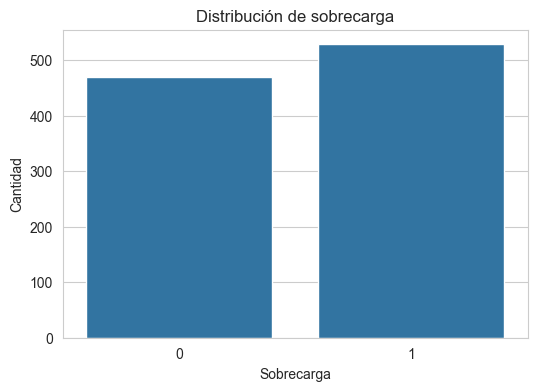

In [13]:
display(df_v3["sobrecarga_kg"].value_counts())
display(df_v3["sobrecarga_kg"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="sobrecarga_kg")

plt.title("Distribución de sobrecarga")
plt.xlabel("Sobrecarga")
plt.ylabel("Cantidad")

plt.show()


## Análisis de sobrecarga

La sobrecarga aparece en una proporción relevante del dataset.

Esto significa que muchas operaciones superan la capacidad nominal del vehículo según el cálculo operacional.

Este hallazgo es importante porque la sobrecarga está relacionada con mayor exigencia, mayor desgaste y mayor riesgo logístico.


# 12. Rutas largas

Analizo la proporción de rutas clasificadas como largas.



ruta_larga
0    740
1    258
Name: count, dtype: int64


ruta_larga
0    74.148297
1    25.851703
Name: proportion, dtype: float64

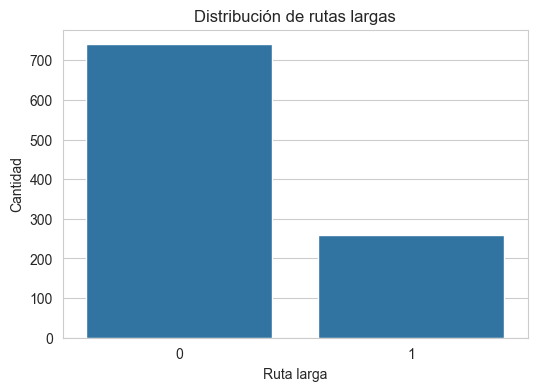

In [14]:
display(df_v3["ruta_larga"].value_counts())
display(df_v3["ruta_larga"].value_counts(normalize=True) * 100)

plt.figure(figsize=(6,4))
sns.countplot(data=df_v3, x="ruta_larga")

plt.title("Distribución de rutas largas")
plt.xlabel("Ruta larga")
plt.ylabel("Cantidad")

plt.show()


## Análisis de rutas largas

Aproximadamente una cuarta parte de las operaciones corresponde a rutas largas.

Esto tiene sentido porque `ruta_larga` fue definida usando un criterio percentil.

Operacionalmente, estas rutas pueden implicar mayor exposición, más tiempo de operación y mayor probabilidad de acumulación de riesgos.


# 13. Top 10 rutas más exigentes

Identifico las rutas con mayor riesgo operacional promedio.



id_ruta
60.0    8996.405263
9.0     4646.337566
49.0    4587.088523
36.0    4246.849992
69.0    3913.393512
41.0    3854.076985
34.0    3669.037023
19.0    3666.398027
16.0    3664.050768
58.0    3499.246184
Name: riesgo_operacional, dtype: float64

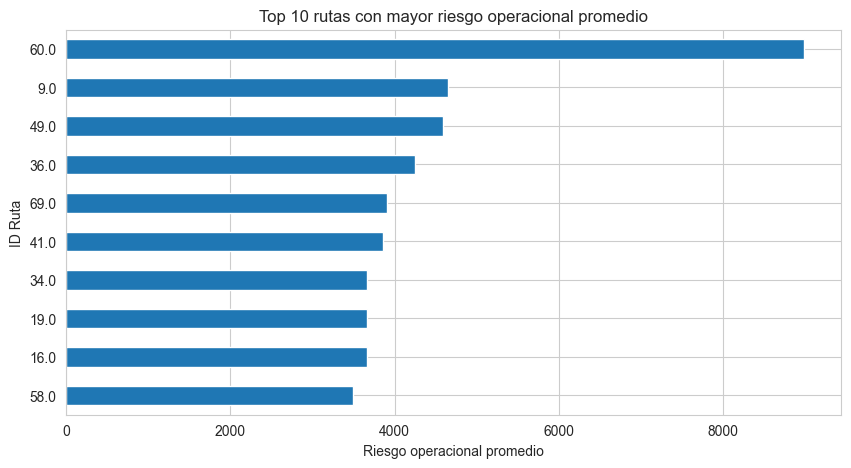

In [15]:
top_rutas = (
    df_v3
    .groupby("id_ruta")["riesgo_operacional"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

display(top_rutas)

plt.figure(figsize=(10,5))
top_rutas.sort_values().plot(kind="barh")

plt.title("Top 10 rutas con mayor riesgo operacional promedio")
plt.xlabel("Riesgo operacional promedio")
plt.ylabel("ID Ruta")

plt.show()


## Análisis de rutas exigentes

El ranking permite identificar rutas que concentran mayor riesgo operacional promedio.

Estas rutas podrían ser candidatas para monitoreo especial, revisión de planificación o asignación de vehículos más adecuados.

Este tipo de análisis es útil porque transforma el dataset en información accionable para la operación logística.


# 14. Mapa de correlaciones

Analizo relaciones entre variables operacionales numéricas.


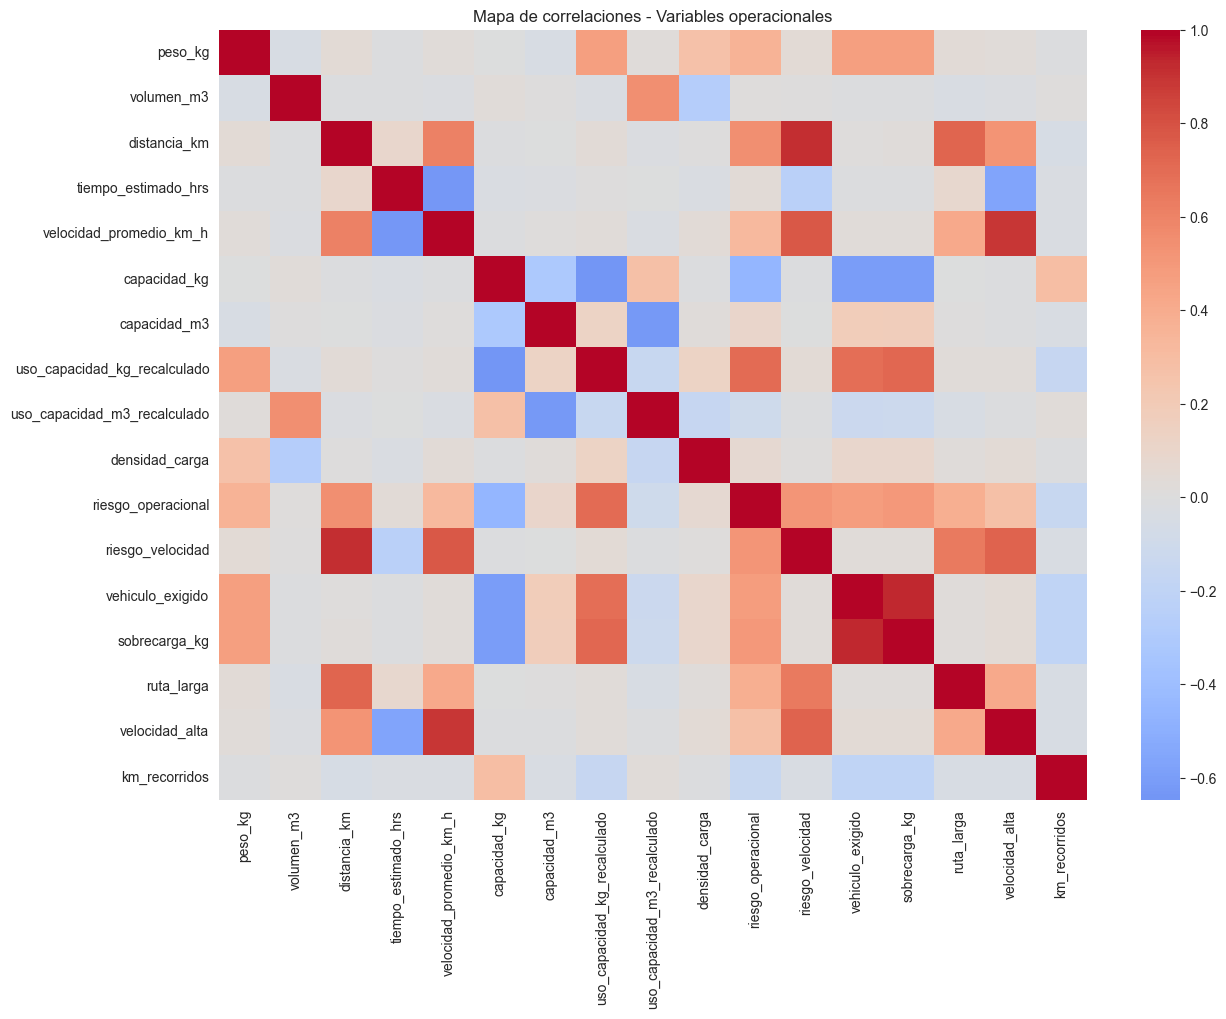

In [16]:
variables_corr = [
    "peso_kg",
    "volumen_m3",
    "distancia_km",
    "tiempo_estimado_hrs",
    "velocidad_promedio_km_h",
    "capacidad_kg",
    "capacidad_m3",
    "uso_capacidad_kg_recalculado",
    "uso_capacidad_m3_recalculado",
    "densidad_carga",
    "riesgo_operacional",
    "riesgo_velocidad",
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "km_recorridos"
]

variables_corr = [col for col in variables_corr if col in df_v3.columns]

corr = df_v3[variables_corr].corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=False
)

plt.title("Mapa de correlaciones - Variables operacionales")

plt.show()


## Análisis del mapa de correlaciones

El mapa de correlaciones permite observar relaciones importantes entre variables operacionales.

Destacan relaciones coherentes como:

- distancia con riesgo operacional;
- uso de capacidad con riesgo operacional;
- sobrecarga con vehículo exigido;
- velocidad con riesgo por velocidad;
- ruta larga con distancia.

Estas relaciones muestran que las variables creadas en la etapa de feature engineering no son aleatorias, sino que representan patrones operacionales interpretables.


# 15. Correlación con riesgo operacional

Ordeno las variables según su correlación con `riesgo_operacional`.


In [17]:
corr_riesgo = (
    corr["riesgo_operacional"]
    .sort_values(ascending=False)
)

corr_riesgo



riesgo_operacional              1.000000
uso_capacidad_kg_recalculado    0.709857
distancia_km                    0.547860
riesgo_velocidad                0.518194
sobrecarga_kg                   0.500248
vehiculo_exigido                0.479811
ruta_larga                      0.385355
peso_kg                         0.356387
velocidad_promedio_km_h         0.327477
velocidad_alta                  0.273212
capacidad_m3                    0.095255
densidad_carga                  0.069296
tiempo_estimado_hrs             0.036081
volumen_m3                      0.009718
uso_capacidad_m3_recalculado   -0.104740
km_recorridos                  -0.147929
capacidad_kg                   -0.448538
Name: riesgo_operacional, dtype: float64

## Análisis de correlación con riesgo operacional

Las variables más asociadas al riesgo operacional son:

- `uso_capacidad_kg_recalculado`;
- `distancia_km`;
- `riesgo_velocidad`;
- `sobrecarga_kg`;
- `vehiculo_exigido`;
- `ruta_larga`;
- `peso_kg`;
- `velocidad_promedio_km_h`.

Esto tiene mucha coherencia con el negocio: el riesgo aumenta cuando los envíos combinan mayor distancia, mayor carga, mayor utilización de capacidad y mayor exigencia operacional.


# 16. Relación entre uso de capacidad y riesgo operacional

Analizo visualmente la relación entre utilización de capacidad y riesgo.


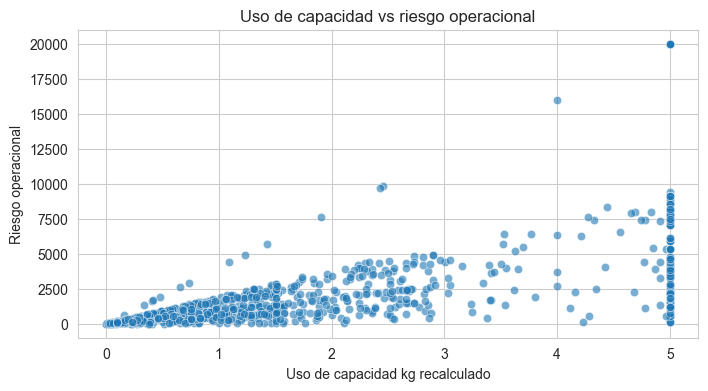

In [18]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_v3,
    x="uso_capacidad_kg_recalculado",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Uso de capacidad vs riesgo operacional")
plt.xlabel("Uso de capacidad kg recalculado")
plt.ylabel("Riesgo operacional")

plt.show()


## Análisis

Se observa una relación positiva clara: cuando aumenta el uso de capacidad, el riesgo operacional tiende a crecer.

Esto confirma que la presión sobre el vehículo es un factor clave dentro del score de riesgo.


# 17. Relación entre distancia y riesgo operacional

Analizo cómo cambia el riesgo según la distancia del envío.


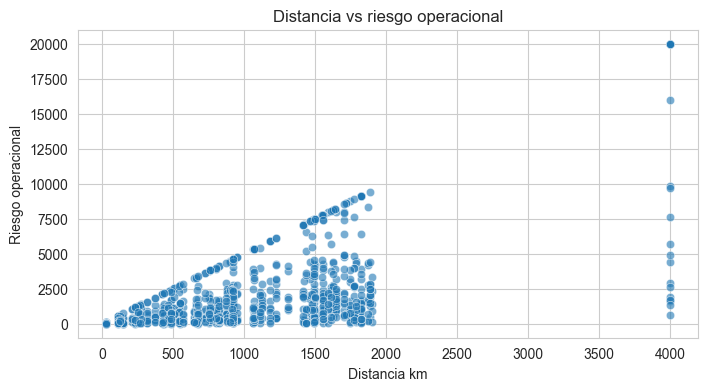

In [19]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_v3,
    x="distancia_km",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Distancia vs riesgo operacional")
plt.xlabel("Distancia km")
plt.ylabel("Riesgo operacional")

plt.show()


## Análisis

La distancia muestra una relación positiva con el riesgo operacional.

Las rutas más largas tienden a presentar mayor exposición operativa, especialmente cuando se combinan con alto uso de capacidad.

Este patrón justifica la creación de variables como `ruta_larga` y `riesgo_operacional`.


# 18. Relación entre velocidad y riesgo operacional

Analizo si la velocidad promedio se relaciona con el riesgo.


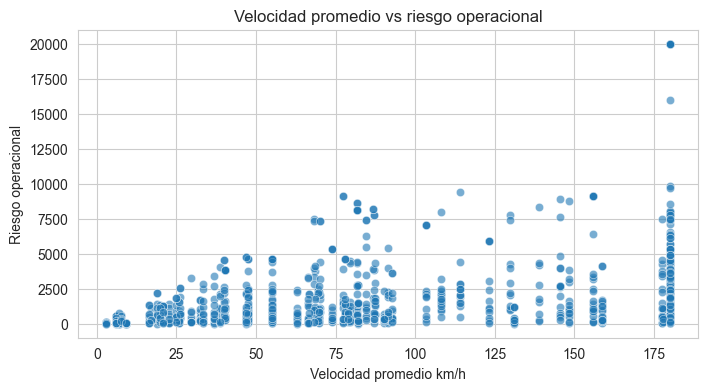

In [20]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_v3,
    x="velocidad_promedio_km_h",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Velocidad promedio vs riesgo operacional")
plt.xlabel("Velocidad promedio km/h")
plt.ylabel("Riesgo operacional")

plt.show()


## Análisis

La velocidad por sí sola no explica completamente el riesgo operacional, pero sí aparece asociada a operaciones más exigentes cuando se combina con distancia y carga.

Por eso también se creó `riesgo_velocidad`, que representa mejor la exposición conjunta entre velocidad y recorrido.


# 19. Relación entre peso y riesgo operacional

Analizo la relación entre peso transportado y riesgo.


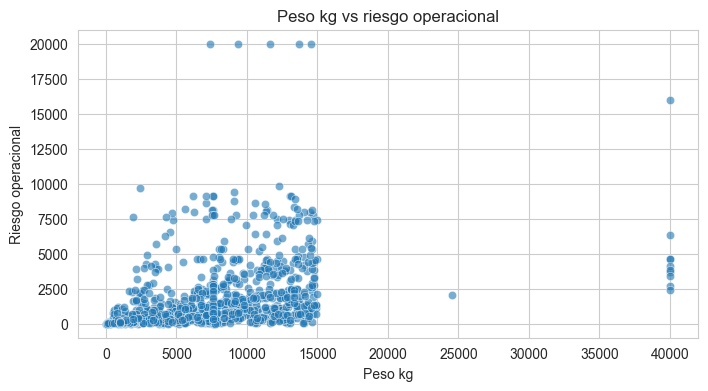

In [21]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_v3,
    x="peso_kg",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Peso kg vs riesgo operacional")
plt.xlabel("Peso kg")
plt.ylabel("Riesgo operacional")

plt.show()


## Análisis

El peso tiene relación con el riesgo, pero no actúa solo.

Un peso alto puede ser más o menos riesgoso dependiendo de la capacidad del vehículo, la distancia y la velocidad.

Esto demuestra que el riesgo operacional no se reduce únicamente a “más peso = más riesgo”, sino que depende de combinaciones entre variables.


# 20. Relación entre densidad de carga y riesgo operacional

Analizo si la densidad de carga se asocia con el riesgo.


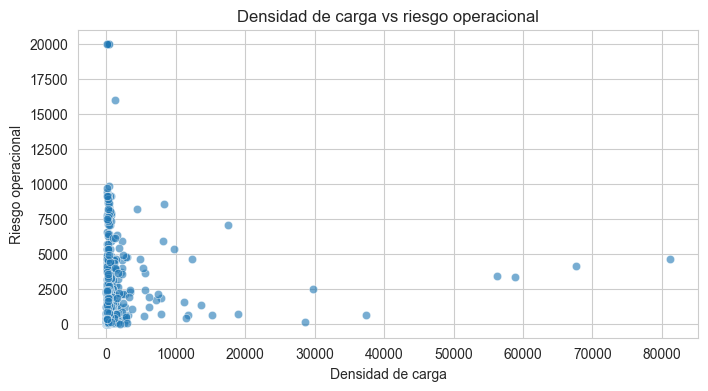

In [22]:
plt.figure(figsize=(8,4))

sns.scatterplot(
    data=df_v3,
    x="densidad_carga",
    y="riesgo_operacional",
    alpha=0.6
)

plt.title("Densidad de carga vs riesgo operacional")
plt.xlabel("Densidad de carga")
plt.ylabel("Riesgo operacional")

plt.show()


## Análisis

La densidad de carga presenta valores muy concentrados en rangos bajos, con algunos casos altos.

Aunque no parece ser la variable más fuerte por sí sola, puede aportar información complementaria sobre el tipo de operación y la relación entre peso y volumen.


# 21. Comparación de riesgo según variables binarias

Analizo cómo cambia el riesgo operacional según variables derivadas como sobrecarga, vehículo exigido, ruta larga y velocidad alta.


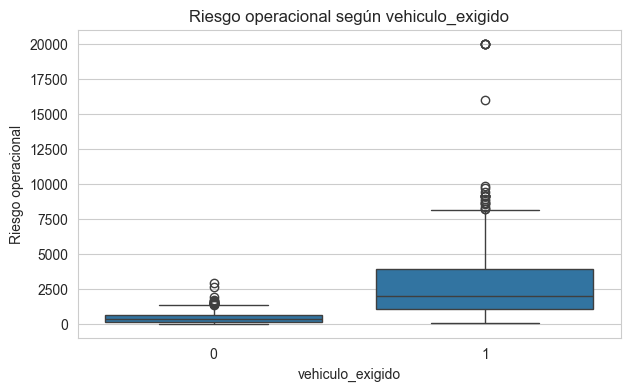

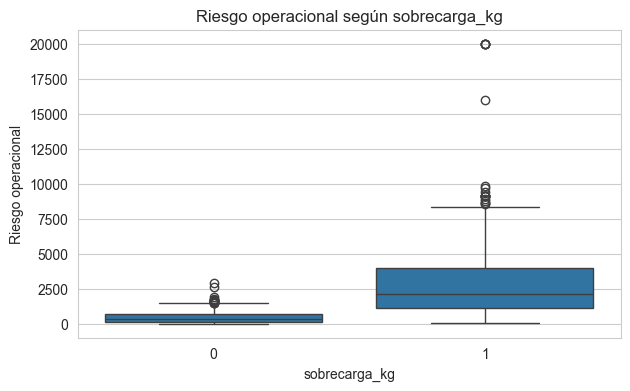

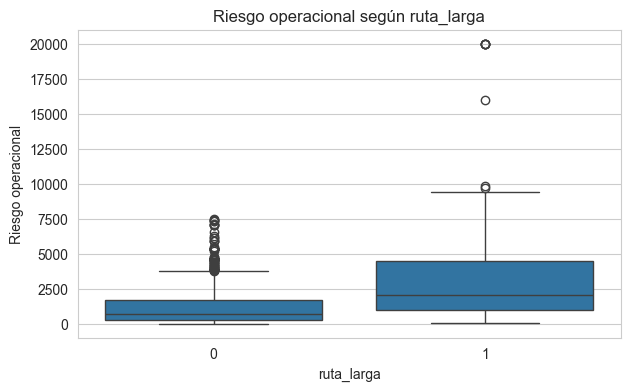

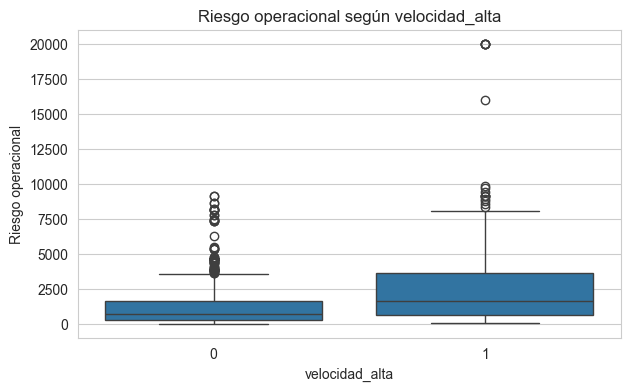

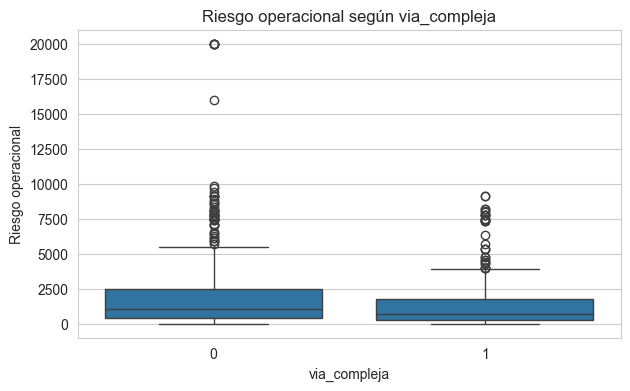

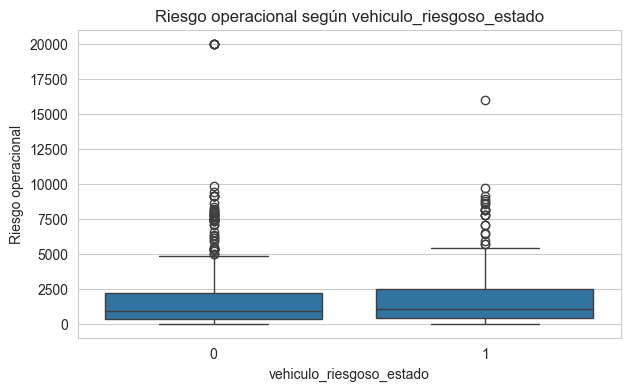

In [23]:
variables_binarias = [
    "vehiculo_exigido",
    "sobrecarga_kg",
    "ruta_larga",
    "velocidad_alta",
    "via_compleja",
    "vehiculo_riesgoso_estado"
]

variables_binarias = [col for col in variables_binarias if col in df_v3.columns]

for col in variables_binarias:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df_v3, x=col, y="riesgo_operacional")
    plt.title(f"Riesgo operacional según {col}")
    plt.xlabel(col)
    plt.ylabel("Riesgo operacional")
    plt.show()


## Análisis de variables binarias

Las variables binarias permiten comparar grupos de forma clara.

En general, se espera que los envíos con vehículo exigido, sobrecarga, ruta larga o velocidad alta presenten mayor riesgo operacional.

Este análisis permite conectar el comportamiento del negocio con variables que luego pueden ser utilizadas por modelos predictivos.


# 22. Hallazgos principales del EDA

A partir del análisis exploratorio se identifican los siguientes hallazgos:

1. La operación tiene diversidad de cargas, vías y estados vehiculares.
2. El riesgo operacional presenta una distribución asimétrica, con pocos envíos muy exigentes.
3. El uso de capacidad es una de las variables más relacionadas con el riesgo.
4. La distancia y las rutas largas aumentan la exposición operacional.
5. La sobrecarga y los vehículos exigidos aparecen como señales relevantes.
6. La velocidad no explica todo el riesgo por sí sola, pero combinada con distancia aporta información.
7. El riesgo operacional depende de combinaciones de variables, no de un solo factor aislado.

Estos hallazgos justifican que el proyecto avance hacia modelos que intenten clasificar y estimar riesgo operacional.


# 23. Conclusiones del notebook

Este notebook permitió comprender el comportamiento general de la operación logística.

El análisis muestra que el dataset V3 contiene patrones coherentes entre carga, capacidad, distancia, velocidad y riesgo.

También se observa que el riesgo operacional es una variable útil para resumir la exigencia de cada envío, ya que se relaciona con factores relevantes del negocio.

La siguiente etapa del proyecto será definir y comparar posibles predicciones, utilizando estos hallazgos como base para justificar el enfoque de modelado.
